# Visualization

In [5]:
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

root_folder = "/Users/lms/Sciebo/Data/TGNNSHAP_data/results"

def load_results(dataset_name: str) -> pd.DataFrame:
    dfs = []
    result_files = {
        "Shapley4TGNNEvent": "Shapley4TGNNEvent.csv",
        "Shapley4TGNNFeature": "Shapley4TGNNFeature.csv",
        "TGNNExplainer": "TGNNExplainer.csv",
        "TempME": "TempME.csv",
        "QIEA-TGX": "QIEA-TGX.csv",
        "Random": "Random.csv",
    }

    for explainer, filename in result_files.items():
        path = f"{root_folder}/{dataset_name}/{filename}"
        if os.path.exists(path):
            result_df = pd.read_csv(path)
            result_df["Explainer"] = explainer
            result_df["Dataset"] = dataset_name
            dfs.append(result_df)
        else:
            print(f"{path} does not exist.")

    if not dfs:
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)


datasets = ["Flights", "mooc", "reddit", "UNtrade", "UNvote", "USLegis", "wikipedia", "WikipediaCAWN"]
results_dict = {d: load_results(d) for d in datasets}


/Users/lms/Sciebo/Data/TGNNSHAP_data/results/Flights/TempME.csv does not exist.
/Users/lms/Sciebo/Data/TGNNSHAP_data/results/WikipediaCAWN/Shapley4TGNNFeature.csv does not exist.
/Users/lms/Sciebo/Data/TGNNSHAP_data/results/WikipediaCAWN/TGNNExplainer.csv does not exist.
/Users/lms/Sciebo/Data/TGNNSHAP_data/results/WikipediaCAWN/TempME.csv does not exist.


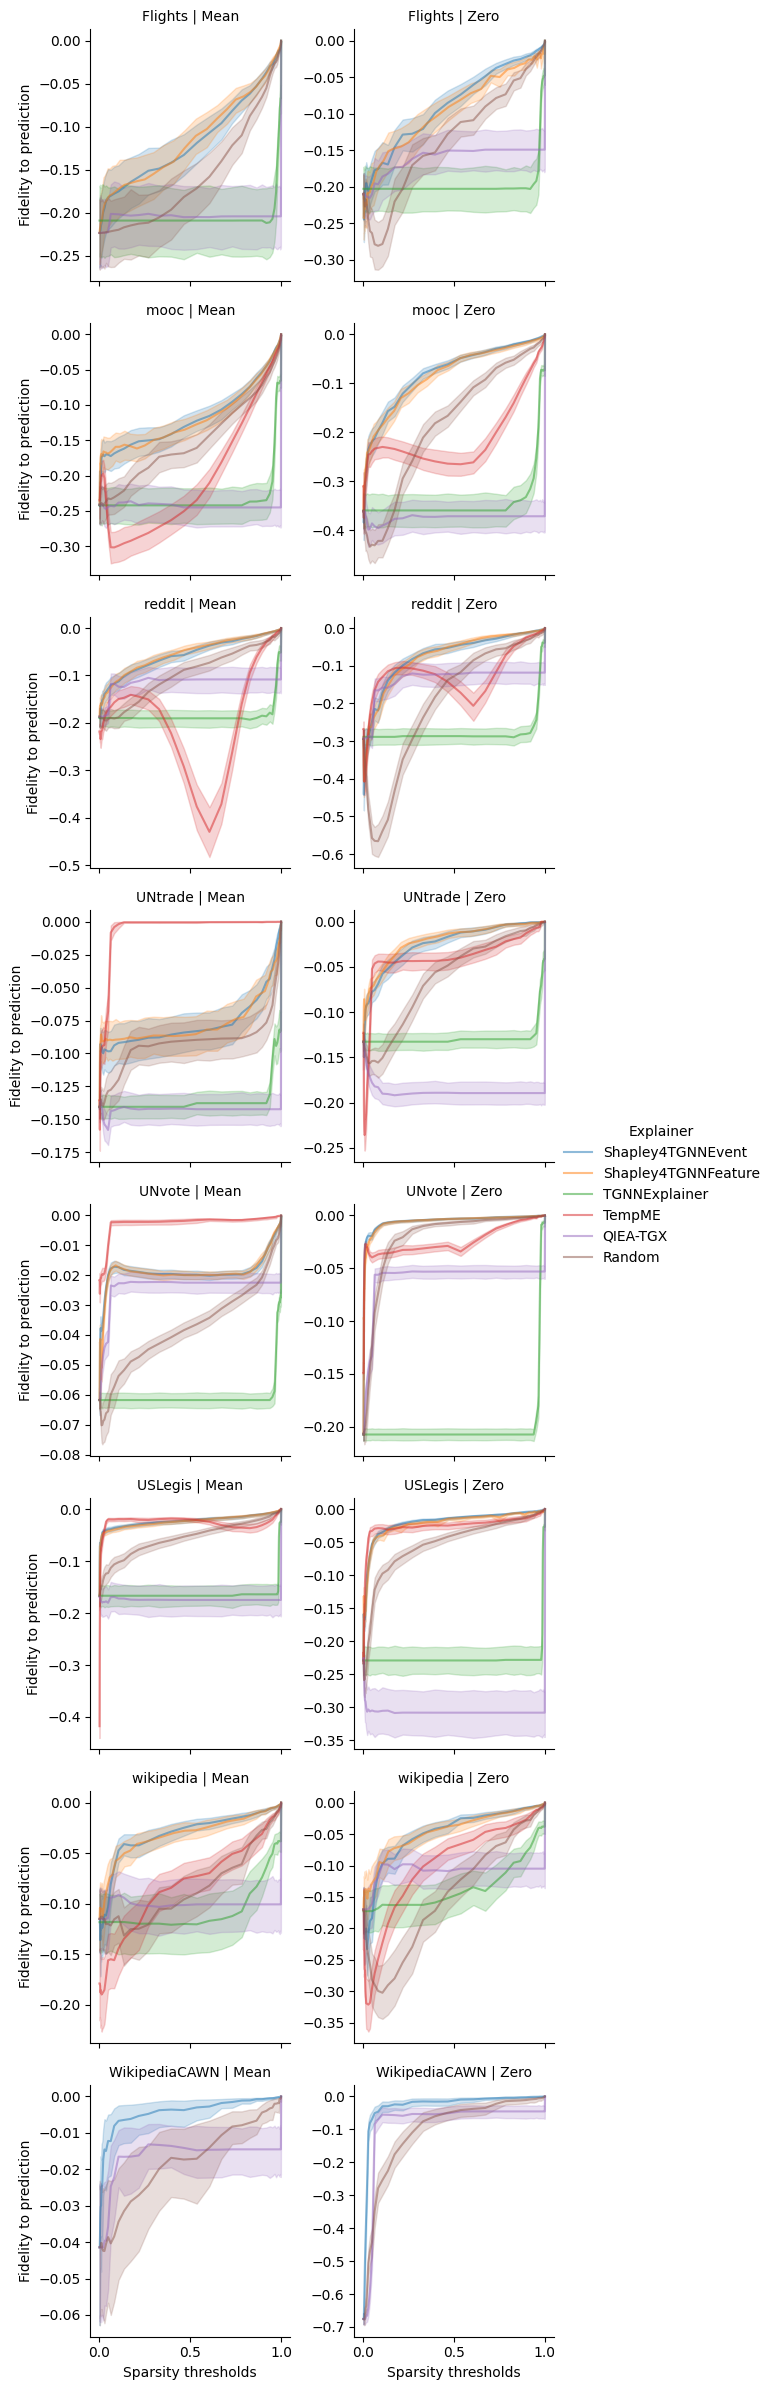

In [ ]:
hue_order = [
    "Shapley4TGNNEvent", "Shapley4TGNNFeature", "TGNNExplainer",
    "TempME", "QIEA-TGX", "Random",
]

df = pd.concat(results_dict.values(), ignore_index=True)

g = sns.FacetGrid(
    df, row="Dataset", col="Remove technique", hue="Explainer", sharey=False,
    sharex=True, hue_order=hue_order,
)
g.map(sns.lineplot, "Sparsity thresholds", "Fidelity to prediction", alpha=0.5)
g.add_legend()
g.set_titles(
    col_template="{col_name}",
    row_template="{row_name}",
)


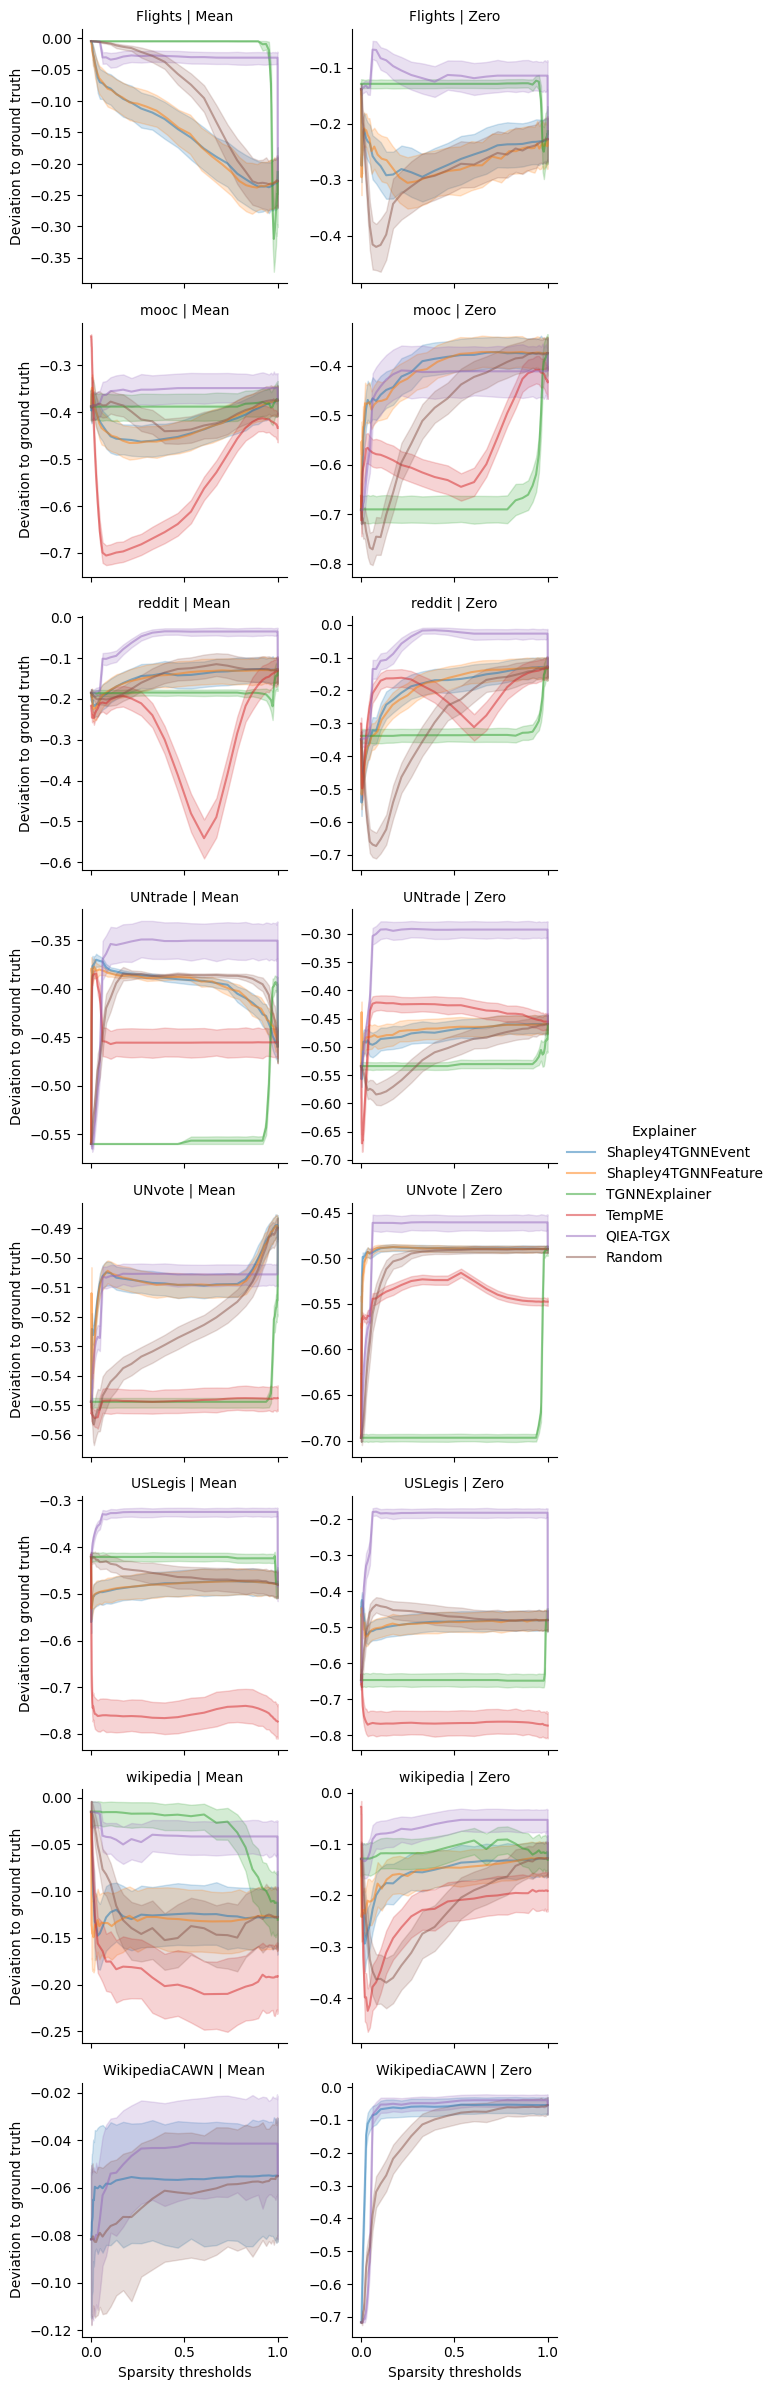

In [8]:
hue_order = [
    "Shapley4TGNNEvent", "Shapley4TGNNFeature", "TGNNExplainer",
    "TempME", "QIEA-TGX", "Random",
]

df = pd.concat(results_dict.values(), ignore_index=True)

g = sns.FacetGrid(
    df, row="Dataset", col="Remove technique", hue="Explainer", sharey=False,
    sharex=True, hue_order=hue_order,
)
g.map(sns.lineplot, "Sparsity thresholds", "Deviation to ground truth", alpha=0.5)
g.add_legend()
g.set_titles(
    col_template="{col_name}",
    row_template="{row_name}",
)

# AUC

In [9]:
from sklearn.metrics import auc
from scipy.integrate import trapezoid

# Change these two names when a different curve should be integrated.
x_column = "Sparsity thresholds"
y_column = "Fidelity to prediction"

group_columns = ["Remove technique", "Explainer", "Instance index"]

result = []

for dataset_name, df in results_dict.items():
    for identifiers, group in df.groupby(group_columns, dropna=False):
        area = trapezoid(group[y_column], group[x_column])
        technique, explainer, instance = identifiers
        result.append({
        "dataset": dataset_name,
        "explainer": explainer,
        "technique": technique,
        "instance": instance,
        "auc": area,
    })

auc_df = pd.DataFrame(result, columns=["dataset", "explainer", "technique", "instance", "auc"])
auc_df

,dataset,explainer,technique,instance,auc
0,Flights,QIEA-TGX,Mean,0,-0.024065
1,Flights,QIEA-TGX,Mean,1,-0.595168
2,Flights,QIEA-TGX,Mean,2,-0.001707
3,Flights,QIEA-TGX,Mean,3,-0.024699
4,Flights,QIEA-TGX,Mean,4,-0.005225
...,...,...,...,...,...
17299,WikipediaCAWN,Shapley4TGNNEvent,Zero,195,-0.062483
17300,WikipediaCAWN,Shapley4TGNNEvent,Zero,196,-0.017315
17301,WikipediaCAWN,Shapley4TGNNEvent,Zero,197,-0.055477
17302,WikipediaCAWN,Shapley4TGNNEvent,Zero,198,-0.016003


## Table

In [10]:
df = auc_df.copy()
df = df.groupby(["dataset", "explainer", "technique"]).agg(
    mean_auc=("auc", "mean"),
    std_auc=("auc", "std"),
    num_samples=("auc", "count"),
).reset_index()

df = df.pivot_table(
    index=["dataset", "explainer"],
    columns="technique",
    values=["mean_auc", "std_auc", "num_samples"],
).reset_index()

df

dataset            explainer  mean_auc           num_samples  \
technique                                          Mean      Zero        Mean   
0                Flights             QIEA-TGX -0.204656 -0.160212       198.0   
1                Flights               Random -0.158522 -0.133427       198.0   
2                Flights    Shapley4TGNNEvent -0.116555 -0.087291       198.0   
3                Flights  Shapley4TGNNFeature -0.114111 -0.093804       198.0   
4                Flights        TGNNExplainer -0.206152 -0.197872       173.0   
5                UNtrade             QIEA-TGX -0.142513 -0.187828       198.0   
6                UNtrade               Random -0.091977 -0.060466       198.0   
7                UNtrade    Shapley4TGNNEvent -0.077921 -0.023382       198.0   
8                UNtrade  Shapley4TGNNFeature -0.077493 -0.020438       198.0   
9                UNtrade        TGNNExplainer -0.136438 -0.128555       198.0   
10               UNtrade               TempME -0.005410 -0.039501       198.0   
11                UNvote             QIEA-TGX -0.023879 -0.059075       198.0   
12                UNvote               Random -0.037228 -0.021040       198.0   
13                UNvote    Shapley4TGNNEvent -0.018738 -0.005079       198.0   
14                UNvote  Shapley4TGNNFeature -0.018907 -0.005556       198.0   
15                UNvote        TGNNExplainer -0.060789 -0.201020       198.0   
16                UNvote               TempME -0.002573 -0.023925       198.0   
17               USLegis             QIEA-TGX -0.174547 -0.307104       151.0   
18               USLegis               Random -0.055722 -0.052066       193.0   
19               USLegis    Shapley4TGNNEvent -0.022546 -0.019200       193.0   
20               USLegis  Shapley4TGNNFeature -0.023338 -0.021318       193.0   
21               USLegis        TGNNExplainer -0.164281 -0.226219       193.0   
22               USLegis               TempME -0.025719 -0.024482       195.0   
23         WikipediaCAWN             QIEA-TGX -0.016327 -0.081430       200.0   
24         WikipediaCAWN               Random -0.017778 -0.100383       200.0   
25         WikipediaCAWN    Shapley4TGNNEvent -0.004189 -0.026074       200.0   
26                  mooc             QIEA-TGX -0.243165 -0.374659       200.0   
27                  mooc               Random -0.150719 -0.180368       200.0   
28                  mooc    Shapley4TGNNEvent -0.118252 -0.077714       200.0   
29                  mooc  Shapley4TGNNFeature -0.119563 -0.081477       200.0   
30                  mooc        TGNNExplainer -0.234577 -0.343713       199.0   
31                  mooc               TempME -0.205385 -0.211702       200.0   
32                reddit             QIEA-TGX -0.114166 -0.134791       199.0   
33                reddit               Random -0.096605 -0.196174       199.0   
34                reddit    Shapley4TGNNEvent -0.056360 -0.072599       199.0   
35                reddit  Shapley4TGNNFeature -0.053944 -0.073409       199.0   
36                reddit        TGNNExplainer -0.203269 -0.308345       199.0   
37                reddit               TempME -0.203488 -0.121523       199.0   
38             wikipedia             QIEA-TGX -0.100963 -0.108521       200.0   
39             wikipedia               Random -0.084582 -0.145026       200.0   
40             wikipedia    Shapley4TGNNEvent -0.030448 -0.048023       200.0   
41             wikipedia  Shapley4TGNNFeature -0.031413 -0.044990       200.0   
42             wikipedia        TGNNExplainer -0.109163 -0.137032       200.0   
43             wikipedia               TempME -0.080995 -0.097212       200.0   

                   std_auc            
technique   Zero      Mean      Zero  
0          198.0  0.259845  0.195978  
1          198.0  0.183916  0.100252  
2          198.0  0.132502  0.079625  
3          198.0  0.130774  0.083243  
4          173.0  0.266099  0.200643  
5          198.0 

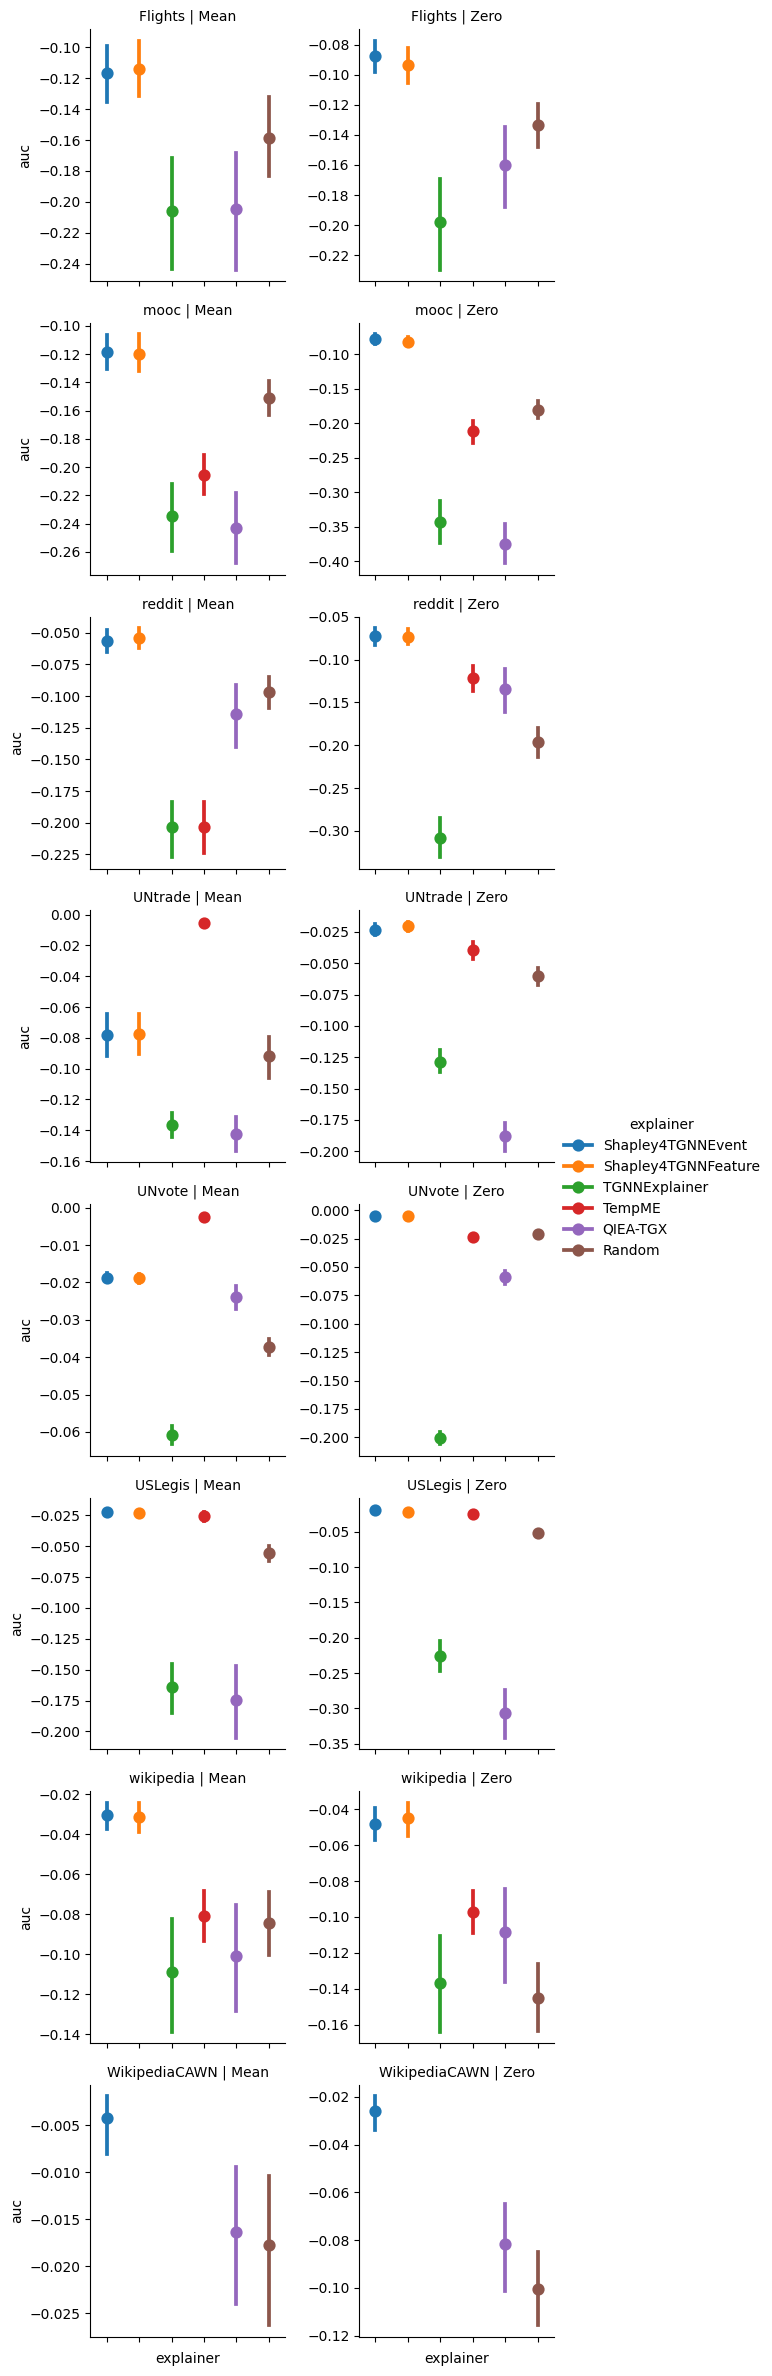

In [20]:
g = sns.FacetGrid(auc_df, row="dataset", col="technique", hue="explainer", sharey=False, sharex=True,
                  hue_order=hue_order)
g.map(sns.pointplot, "explainer", "auc", order=hue_order)
g.add_legend()
g.set_titles(
    col_template="{col_name}",
    row_template="{row_name}",
)
g.set_xticklabels("")

In [35]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

shap_event_auc = auc_df[(auc_df["Explainer"] == "Shapley4TGNNEvent") & (auc_df["technique"] == "Zero")]
shap_feature_auc = auc_df[(auc_df["Explainer"] == "Shapley4TGNNFeature") & (auc_df["technique"] == "Zero")]
tgnn_auc = auc_df[(auc_df["Explainer"] == "TGNNExplainer") & (auc_df["technique"] == "Zero")]
tempme_auc = auc_df[(auc_df["Explainer"] == "TempME") & (auc_df["technique"] == "Zero")]
random_auc = auc_df[(auc_df["Explainer"] == "Random") & (auc_df["technique"] == "Zero")]

df_shap_event_vs_tempme = shap_event_auc.merge(tempme_auc, on=["Dataset", "technique", "instance"], suffixes=('_shap_event', '_tempme'))
df_shap_event_vs_tgnn = shap_event_auc.merge(tgnn_auc, on=["Dataset", "technique", "instance"], suffixes=('_shap_event', '_tgnn'))
df_shap_event_vs_random = shap_event_auc.merge(random_auc, on=["Dataset", "technique", "instance"], suffixes=('_shap_event', '_random'))

df_shap_feat_vs_tempme = shap_feature_auc.merge(tempme_auc, on=["Dataset", "technique", "instance"], suffixes=('_shap_feat', '_tempme'))    
df_shap_feat_vs_tgnn = shap_feature_auc.merge(tgnn_auc, on=["Dataset", "technique", "instance"], suffixes=('_shap_feat', '_tgnn'))
df_shap_feat_vs_random = shap_feature_auc.merge(random_auc, on=["Dataset", "technique", "instance"], suffixes=('_shap_feat', '_random'))

statistic1, p_value1 = wilcoxon(df_shap_event_vs_tempme['AUC_shap_event'], df_shap_event_vs_tempme['AUC_tempme'], alternative="greater")
statistic2, p_value2 = wilcoxon(df_shap_event_vs_tgnn['AUC_shap_event'], df_shap_event_vs_tgnn['AUC_tgnn'], alternative="greater")
statistic3, p_value3 = wilcoxon(df_shap_event_vs_random['AUC_shap_event'], df_shap_event_vs_random['AUC_random'], alternative="greater")
statistic4, p_value4 = wilcoxon(df_shap_feat_vs_tempme['AUC_shap_feat'], df_shap_feat_vs_tempme['AUC_tempme'], alternative="greater")
statistic5, p_value5 = wilcoxon(df_shap_feat_vs_tgnn['AUC_shap_feat'], df_shap_feat_vs_tgnn['AUC_tgnn'], alternative="greater")
statistic6, p_value6 = wilcoxon(df_shap_feat_vs_random['AUC_shap_feat'], df_shap_feat_vs_random['AUC_random'], alternative="greater")

corrected1 = multipletests([p_value1, p_value2, p_value3], method='bonferroni')[1]
corrected2 = multipletests([p_value4, p_value5, p_value6], method='bonferroni')[1]

print("Wilcoxon signed-rank test results for Shapley4TGNNEvent vs other explainers:")
print(statistic1, p_value1)
print(statistic2, p_value2)
print(statistic3, p_value3)
print("\nWilcoxon signed-rank test results for Shapley4TGNNFeature vs other explainers:")
print(statistic4, p_value4)
print(statistic5, p_value5)
print(statistic6, p_value6)

print("\nCorrected p-values for Shapley4TGNNEvent vs other explainers:")
print(corrected1)
print("\nCorrected p-values for Shapley4TGNNFeature vs other explainers:")
print(corrected2)

Wilcoxon signed-rank test results for Shapley4TGNNEvent vs other explainers:
275554.0 1.856259332561125e-58
329373.0 1.5712356628635264e-113
469582.0 3.284790592482376e-113

Wilcoxon signed-rank test results for Shapley4TGNNFeature vs other explainers:
276348.0 2.759842587070967e-59
327196.0 1.861406613806264e-110
465713.0 3.4920761899534685e-109

Corrected p-values for Shapley4TGNNEvent vs other explainers:
[5.56877800e-058 4.71370699e-113 9.85437178e-113]

Corrected p-values for Shapley4TGNNFeature vs other explainers:
[8.27952776e-059 5.58421984e-110 1.04762286e-108]


# Computation times

In [21]:
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

root_folder = "/Users/lms/Sciebo/Data/TGNNSHAP_data/results"

def load_results(dataset_name: str) -> pd.DataFrame:
    dfs = []
    timing_files = {
        "Shapley4TGNNEvent": "Shapley4TGNNEvent_timings.csv",
        "Shapley4TGNNFeature": "Shapley4TGNNFeature_timings.csv",
        "TGNNExplainer": "TGNNExplainer_timings.csv",
        "TempME": "TempME_timings.csv",
        "QIEA-TGX": "QIEA-TGX_timings.csv",
        "Random": "Random_timings.csv",
    }

    for explainer, filename in timing_files.items():
        path = f"{root_folder}/{dataset_name}/{filename}"
        if os.path.exists(path):
            timing_df = pd.read_csv(path)
            timing_df["Explainer"] = explainer
            dfs.append(timing_df)
        else:
            print(f"{path} does not exist.")

    if not dfs:
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)


datasets = ["Flights", "mooc", "reddit", "UNtrade", "UNvote", "USLegis", "wikipedia", "WikipediaCAWN"]
results_dict = {d: load_results(d) for d in datasets}
for df in results_dict.values():
    mean = df.loc[(df["Explainer"]=="QIEA-TGX") & (df["Stage"] == "Explain"), ["Time(ns)", "Time(s)"]] / 19
    df.loc[(df["Explainer"]=="QIEA-TGX") & (df["Stage"] == "Explain"), ["Time(ns)", "Time(s)"]] = mean

/Users/lms/Sciebo/Data/TGNNSHAP_data/results/Flights/TempME_timings.csv does not exist.
/Users/lms/Sciebo/Data/TGNNSHAP_data/results/WikipediaCAWN/Shapley4TGNNFeature_timings.csv does not exist.
/Users/lms/Sciebo/Data/TGNNSHAP_data/results/WikipediaCAWN/TGNNExplainer_timings.csv does not exist.
/Users/lms/Sciebo/Data/TGNNSHAP_data/results/WikipediaCAWN/TempME_timings.csv does not exist.


/var/folders/8g/rhgpcvc52lb5zf0nk7xqdprm0000gn/T/ipykernel_6176/1914356667.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[8.96374099e+09 5.31970141e+09 9.80268604e+09 7.81422934e+09
 5.84163526e+09 9.81006485e+09 9.90778053e+09 9.30664739e+09
 7.35289269e+09 1.01310615e+10 7.19701489e+09 9.09095957e+09
 9.38691780e+09 6.13753701e+09 8.12529905e+09 8.94205789e+09
 9.32832067e+09 7.30385550e+09 7.80025452e+09 9.04476196e+09
 1.03482536e+10 8.24437125e+09 1.01941793e+10 4.70003716e+09
 9.26147430e+09 8.87189313e+09 6.72811780e+09 1.04163508e+10
 1.04630280e+10 9.98889416e+09 9.97926706e+09 6.10017715e+09
 9.62008145e+09 9.91956566e+09 4.84082624e+09 9.10721822e+09
 9.98127889e+09 9.23363571e+09 9.07381983e+09 8.48366075e+09
 6.73701933e+09 8.10213860e+09 6.51834476e+09 8.61190301e+09
 9.84064823e+09 6.53699541e+09 9.54170440e+09 8.30291781e+09
 8.62396340e+09 6.37421922e+09 6.22002218e+09 1.00302409e

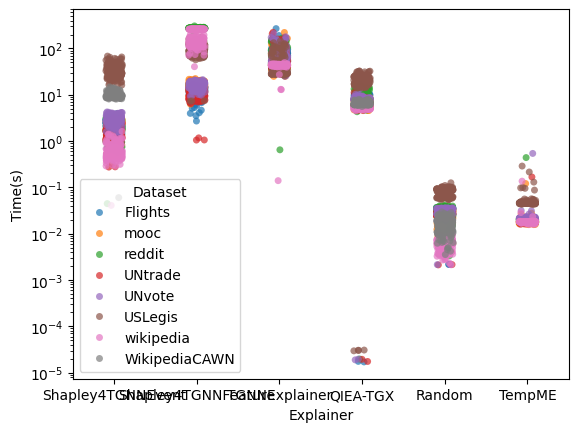

In [22]:
for dataset_name, df in results_dict.items():  
    df["Dataset"] = dataset_name

df = pd.concat(results_dict.values(), ignore_index=True)

#jitter plot
sns.stripplot(data=df[df["Stage"]=="Explain"], x="Explainer", y="Time(s)", hue="Dataset", jitter=True, alpha=0.7)
#Log scale for y-axis
plt.yscale("log")

# Approximation quality

In [28]:
root = "/Users/lms/Sciebo/Data/TGNNSHAP_data/generated_explanations"

def load_results(dataset_name: str) -> pd.DataFrame:
    
    path = f"{root}/{dataset_name}/Shapley4TGNNFeature.csv"
    if os.path.exists(path):
        df = pd.read_csv(path, index_col=None)
        df["dataset"] = dataset_name
    else:
        print(f"{path} does not exist.")
        return pd.DataFrame()
    return df

    

datasets = ["Flights", "mooc", "reddit", "UNtrade", "UNvote", "wikipedia"]
results = pd.concat([load_results(d) for d in datasets], ignore_index=True)

In [29]:
results.head()

,e_id,explained_e_id,rep,time_taken,model,num_samples,explanations,dataset
0,677168,644640,0,2.780130,monte_carlo,5,"[-0.0004875361919403076, -4.547851858660579e-0...",Flights
1,677168,644640,1,1.789507,monte_carlo,5,"[-0.00041703582974150777, -4.815460124518722e-...",Flights
2,677168,644640,2,1.770825,monte_carlo,5,"[-0.0004526595294009894, 0.0001618882088223472...",Flights
3,677168,644640,3,1.767479,monte_carlo,5,"[-0.0003156205057166517, 4.0797389374347404e-0...",Flights
4,677168,644640,4,1.732216,monte_carlo,5,"[-0.0002802610397338867, 0.0002803623501677066...",Flights


In [30]:
def to_float_array(value) -> np.ndarray:
    """Convert an explanation value to a one-dimensional float array."""
    if isinstance(value, np.ndarray):
        return value.astype(float, copy=False).ravel()
    if isinstance(value, (list, tuple)):
        return np.asarray(value, dtype=float).ravel()
    if isinstance(value, str):
        # Handles values loaded from CSV, e.g. "[0.1 0.2 0.3]" or "[0.1, 0.2, 0.3]".
        value = value.strip().strip("[]")
        return np.fromstring(value, sep=",") if "," in value else np.fromstring(value, sep=" ")
    return np.asarray(value, dtype=float).ravel()


def summarize_explanations(group: pd.Series) -> pd.Series:
    explanations = np.stack(group.map(to_float_array).to_numpy())
    explanations_normalized = explanations
    column_variances = np.var(explanations_normalized, axis=0, ddof=1)
    return column_variances.mean()


explanation_summary = (
    results.groupby(["e_id", "explained_e_id", "num_samples", "dataset"], dropna=False)["explanations"]
    .apply(summarize_explanations)
    .rename("mean_explanation_variance")
    .reset_index()
)

times_summary = (
    results.groupby(["e_id", "explained_e_id", "num_samples", "dataset"], dropna=False)["time_taken"]
    .mean()
    .rename("mean_time")
    .reset_index()
)

summary = pd.merge(explanation_summary, times_summary, on=["e_id", "explained_e_id", "num_samples", "dataset"], how="outer")

summary.head()


,e_id,explained_e_id,num_samples,dataset,mean_explanation_variance,mean_time
0,21641,3296,5,mooc,1.638212e-07,1.460845
1,21641,3296,337,mooc,3.250036e-09,2.461945
2,21641,3296,670,mooc,1.739382e-09,3.770709
3,21641,3296,1003,mooc,1.389365e-09,4.261401
4,21641,3296,1336,mooc,3.885632e-10,4.263028


/var/folders/8g/rhgpcvc52lb5zf0nk7xqdprm0000gn/T/ipykernel_6176/1892153178.py:43: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax1.legend(lines, labels, loc="best")


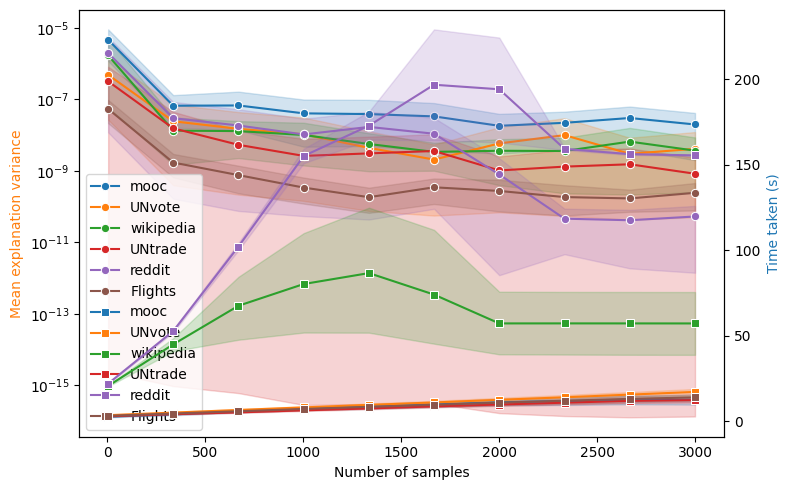

In [31]:
df = summary.copy()

time_color = "tab:blue"
deviation_color = "tab:orange"

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

sns.lineplot(
    data=df,
    x="num_samples",
    y="mean_explanation_variance",
    marker="o",
    ax=ax1,
    hue="dataset",
    #label="Mean explanation variance"
)
ax1.set_ylabel("Mean explanation variance", color=deviation_color)
ax1.tick_params(axis="y")
ax1.set_yscale("log")
ax1.set_xlabel("Number of samples")


sns.lineplot(
    data=df,
    x="num_samples",
    y="mean_time",
    marker="s",
    ax=ax2,
    hue="dataset",
    #label="Time taken (s)",
)
ax2.set_ylabel("Time taken (s)", color=time_color)
ax2.tick_params(axis="y")


ax1.get_legend().remove()
ax2.get_legend().remove()

# Combined legend
lines = ax1.get_lines() + ax2.get_lines()
labels = [str(line.get_label()) for line in lines]
ax1.legend(lines, labels, loc="best")

plt.tight_layout()
plt.show()


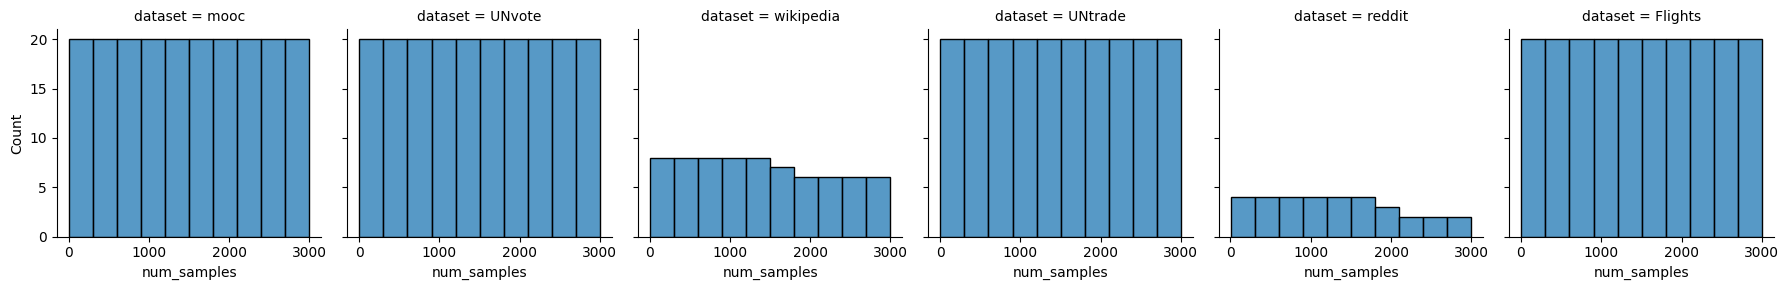

In [32]:
# Sanity check to make sure all sample sizes are present for each dataset
g = sns.FacetGrid(df, col="dataset", sharey=True, sharex=True)
g.map(sns.histplot, "num_samples", bins=10, kde=False)